In [1]:
import json
import numpy as np
_dataset_path = "mapelite/datasets/track_embeddings_metrics_32dim_rngMixDS.npz"
_data = np.load(_dataset_path)
_embeddings = _data["embeddings"]

CVT_PATH = "data/Archive/CVT/cvt run 2/cvt/"

cvt_elites_path = CVT_PATH + "elites.json"

with open(cvt_elites_path, "r") as f:
    elites_data = json.load(f)

# print the outline of the JSON structure
metadata = elites_data["metadata"]
elites = elites_data["elites"]
print("Number of elites:", len(elites))

Number of elites: 300


In [2]:
ids = [938.7034523475282, 346.74691115866176]
elite_dict = {elite["id"]: elite["embedding"] for elite in elites}
selected_embeddings = [elite_dict[i] for i in ids]

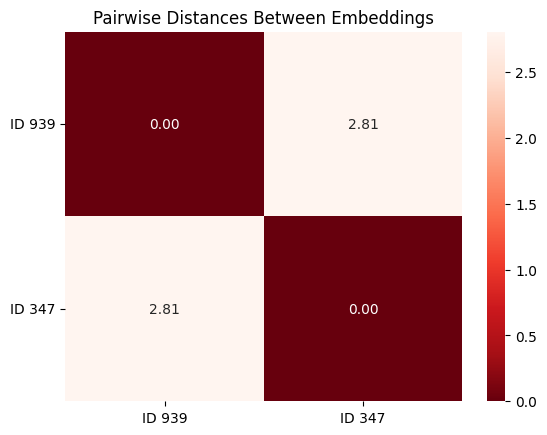

In [3]:
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

latent_distance_matrix = squareform(pdist(selected_embeddings, metric="euclidean"))

# shorten labels for readability
labels = [f"ID {id:.0f}" for id in ids]

sns.heatmap(latent_distance_matrix, annot=True, cmap="Reds_r", xticklabels=labels, yticklabels=labels, fmt=".2f")
plt.title("Pairwise Distances Between Embeddings")
plt.yticks(rotation=0)
plt.show()

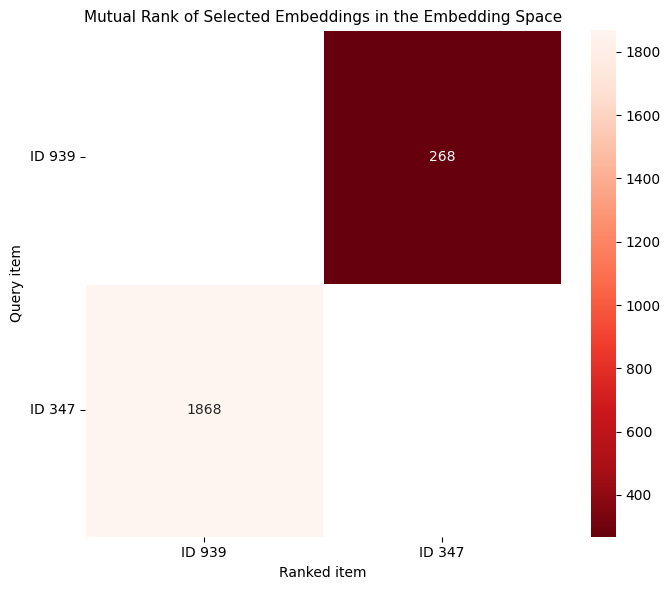

In [4]:
from sklearn.metrics.pairwise import euclidean_distances

all_embeddings = np.array(_embeddings)
selected_embeddings_vecs = np.array(selected_embeddings)
all_embeddings = np.vstack((all_embeddings, selected_embeddings_vecs))

# compute distances from each selected embedding to all embeddings
distances = euclidean_distances(selected_embeddings_vecs, all_embeddings)

# Rank all embeddings for each selected embedding (ascending: closest first)
rankings = np.argsort(distances, axis=1)

# print where each selected_embedding is in the ranking of the others
n_all = len(all_embeddings)
n_selected = len(selected_embeddings_vecs)
selected_indices = list(range(n_all - n_selected, n_all))

# Build rank matrix: rank_matrix[i][j] = rank of ids[j] in ids[i]'s ranking
rank_matrix = np.full((n_selected, n_selected), np.nan)

for i, sel_idx in enumerate(selected_indices):
    for j, other_idx in enumerate(selected_indices):
        if i == j:
            continue
        position = np.where(rankings[i] == other_idx)[0][0]
        rank_matrix[i][j] = position

# Short labels for readability
labels = [f"ID {id:.0f}" for id in ids]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    rank_matrix,
    annot=True,
    fmt=".0f",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Reds_r",      # lower rank (closer) = darker
    linewidths=0.5,
    ax=ax,
    mask=np.eye(n_selected, dtype=bool)  # mask diagonal (self)
)
ax.set_title("Mutual Rank of Selected Embeddings in the Embedding Space", fontsize=11)
ax.set_xlabel("Ranked item")
ax.set_ylabel("Query item")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

2026-03-24 10:28:39 [info     ] Checkpoint loaded              path='data/Archive/CVT/cvt run 2/cvt/checkpoints\\checkpoint_0999.pkl' resume_iter=1000


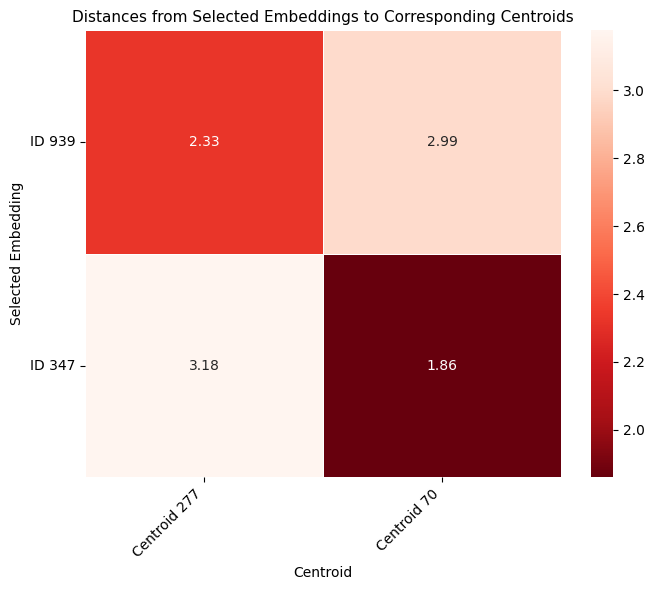

In [ ]:
import sys
from mapelite.qd_runner import QDRunner
import mapelite.emitter as emitter_module
import mapelite.utils as utils_module
import mapelite.config as config_module
from scipy.spatial.distance import pdist, squareform
# Teach pickle that the old top-level 'emitter' is now 'mapelite.emitter'
sys.modules['emitter'] = emitter_module
sys.modules['utils'] = utils_module
sys.modules['config'] = config_module


# load from checkpoint
checkpoint_dir = CVT_PATH + "checkpoints/"
state = QDRunner.get_state_from_checkpoint(checkpoint_dir)
archive = state["archive"]

centroids = getattr(archive, "centroids", None)

selected_centroid_idxs = archive.index_of(selected_embeddings_vecs)
selected_centroids = np.array(centroids[selected_centroid_idxs])

distances = euclidean_distances(selected_embeddings_vecs, selected_centroids)

# Short labels for readability
labels_y = [f"ID {id:.0f}" for id in ids]
labels_x = [f"Centroid {idx}" for idx in selected_centroid_idxs]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    distances,
    annot=True,
    fmt=".2f",
    xticklabels=labels_x,
    yticklabels=labels_y,
    cmap="Reds_r",      # lower rank (closer) = darker
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Distances from Selected Embeddings to Corresponding Centroids", fontsize=11)
ax.set_xlabel("Centroid")
ax.set_ylabel("Selected Embedding")
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()